# Machine Learning - Practical 3 - Multiclass Logistic Regression, MLP and CNNs


Names: {YOUR NAMES}  
Summer Term 2026

**Please note that this practical requires training a lot of models, which may be time consuming (~2h)**

In this practical we will implement multiclass classification with classic Logistic Regression, Multilayer Perceptron, and the convolutional neural network LeNet5 on image data. We will compare the performance of these models. You will work on the following:

 1. Imports and Hardware check
 2. Loading data and related transformations 
 3. Defining training helper functions and metrics 
 4. Logistic Regression 
 5. MLP
 6. CNN
 7. Comparison of results across models

We'll be storing all the losses and accuracies while training, and plotting everything in the end. Use `tqdm` to keep track of your training and validation losses and accuracies since we're only plotting them in the end.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import torchsummary


torch.manual_seed(42) # Set manual seed

In [2]:
# DO NOT CHANGE
use_cuda = True
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


## Define data transformations

We will work with the CIFAR-10 dataset, an established computer vision dataset used for object recognition. It is a subset of the 80 million tiny images dataset and consists of 60,000 32x32 color images containing one of 10 object classes, with 6000 images per class. It was collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The goal of this dataset is to predict the image class.

Note: The constants in `transforms.Normalize()` are the means and standard deviations of the three color channels of the images in the CIFAR-10 training set. You can verify these numbers yourself by re-computing them.

In [3]:
batch_size = 256

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

In [4]:
#skip certificate verification for downloading the dataset
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
# Load the data and transform the dataset
train_dataset =  datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

In [6]:
# You can verify the mean and standard deviation used in the normalization above by calculating the mean and std of the training dataset above. 

train_dataset_raw = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=False,  # already downloaded
    transform=transforms.ToTensor()  # only ToTensor, no Normalize!
)

data = torch.stack([img for img, _ in train_dataset_raw])
mean = data.mean(dim=[0, 2, 3])
std = data.std(dim=[0, 2, 3])

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4914, 0.4822, 0.4465])
Std: tensor([0.2470, 0.2435, 0.2616])


In [7]:
# TODO: make dataloaders (from torch.utils) from datasets, define batch size and do not forget shuffling 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  

In [8]:
## TODO: plot images with their labels after augmentations
def show_batch(dl):

    # get one batch
    images, labels = next(iter(dl))
    
    # plot first 64 images in a 8x8 grid
    fig, axes = plt.subplots(8, 8, figsize=(16, 16))
    for i, ax in enumerate(axes.flat):
        # unnormalize the image
        img = images[i].permute(1, 2, 0)  # (3, 32, 32) → (32, 32, 3)
        img = img * torch.tensor([0.2470, 0.2435, 0.2616]) + torch.tensor([0.4914, 0.4822, 0.4465])
        ax.imshow(img.clip(0, 1))
        ax.set_title(dl.dataset.classes[labels[i]])
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

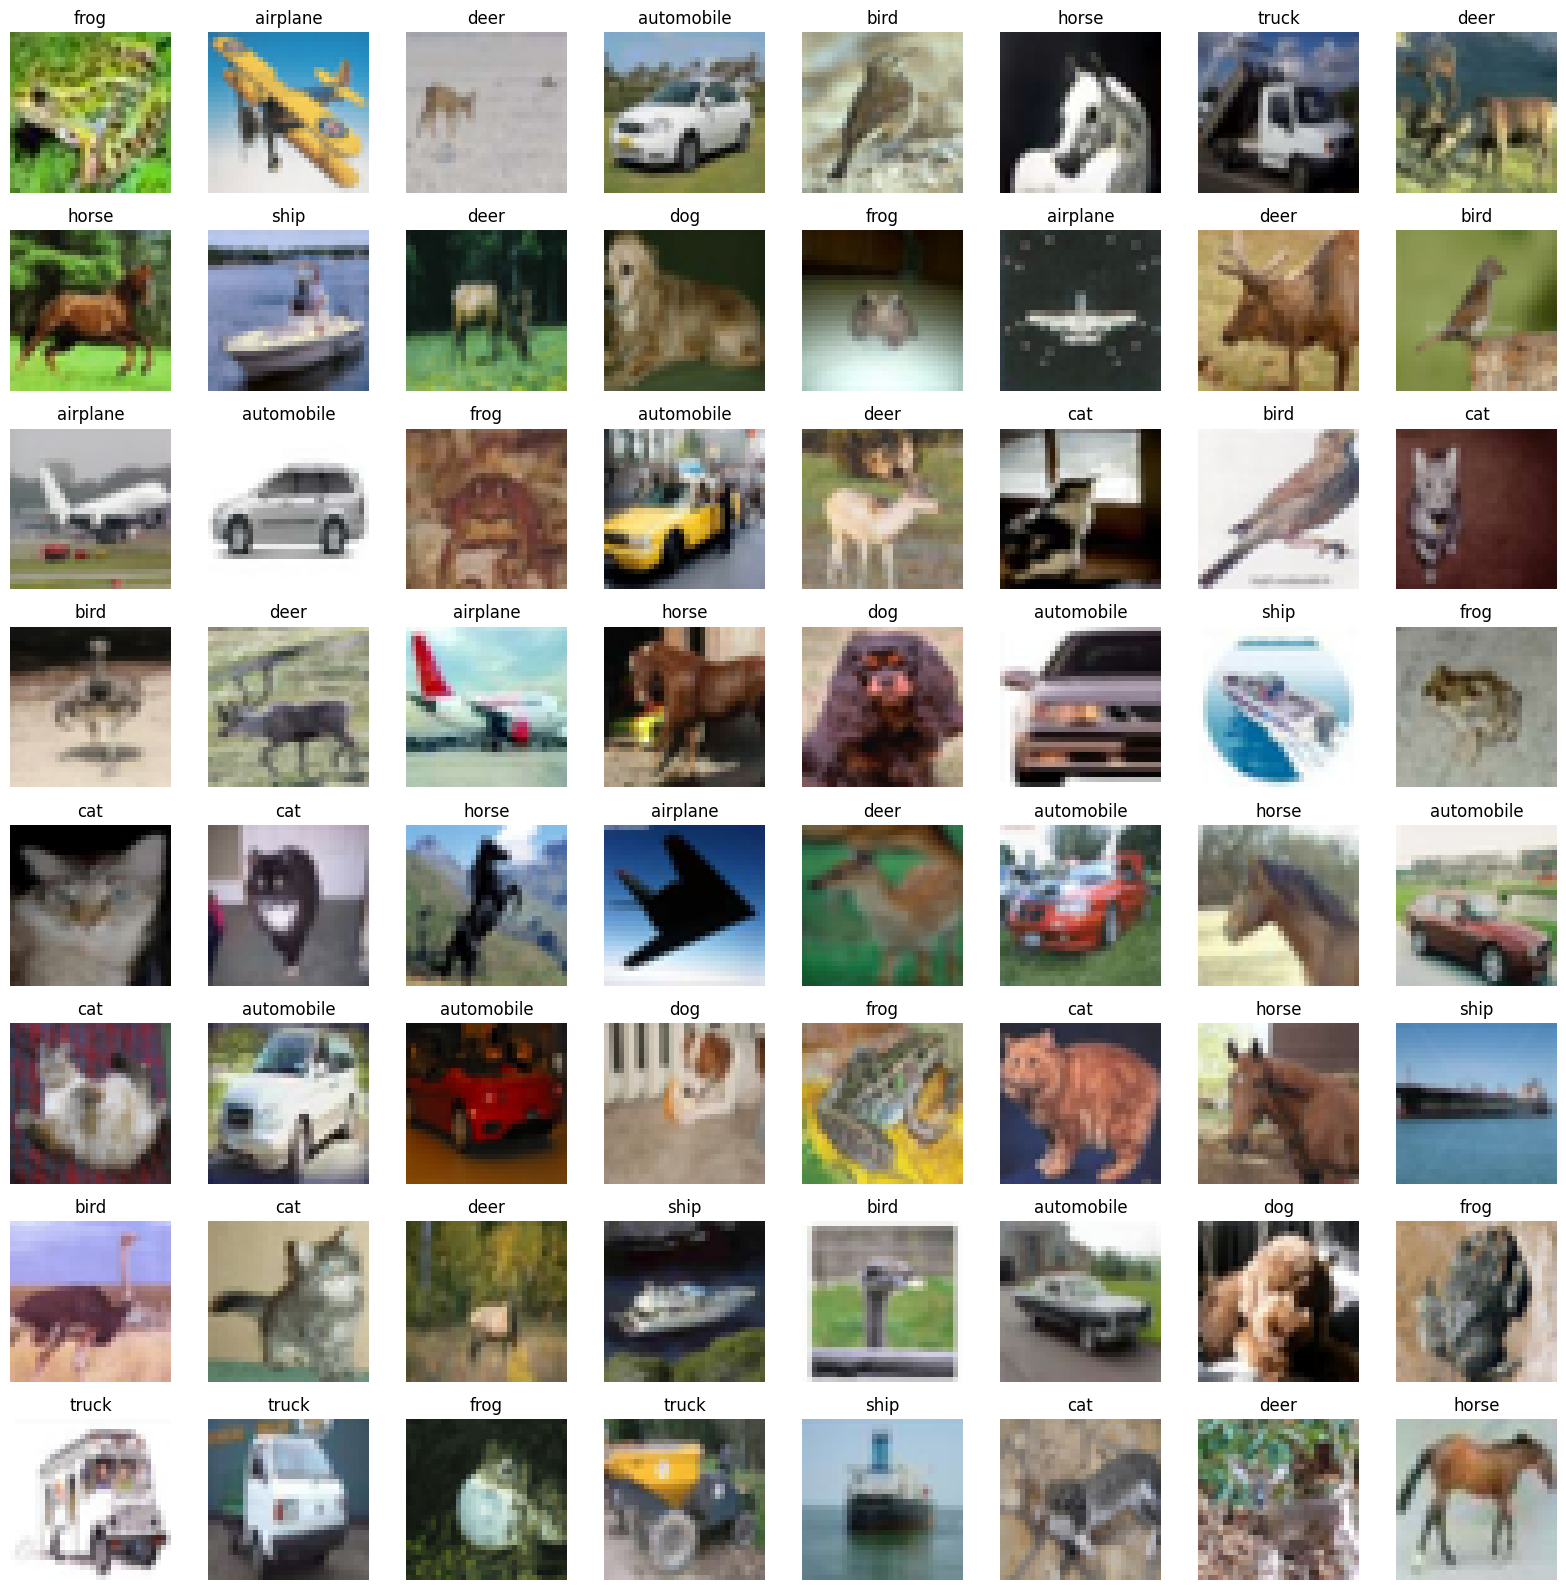

In [9]:
show_batch(train_loader)

In [10]:
num_classes = 10

## Define helper functions for training and metrics

You will need these again and again. 

In [11]:
## TODO: write a function that calculates the accuracy

def accuracy(correct, total): 
    """
    function to calculate the accuracy given the
        correct: number of correctly classified samples
        total: total number of samples
    returns the ratio
    """
    return correct / total

In [12]:
## TODO: Define a train and validation functions here
## Hint - you can use yours from Practical 2 


def train(dataloader, optimizer, model, loss_fn, device, master_bar):
    """ method to train the model """

    # TODO: refine the training function from above
  # it should contain:
  # - saving of losses
  # - calculation of accuracy
  # - returning the mean loss and accuracy

    model.train()  # set model to training mode
    
    total_loss = 0
    correct = 0
    total = 0
    
    #loop through all batches in the dataloader
    for images, labels in dataloader:
        # move data to device (GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        
        # reset gradients from previous batch
        optimizer.zero_grad()
        
        # forward pass: let model make predictions
        predictions = model(images)
        
        # calculate loss
        loss = loss_fn(predictions, labels)
        
        # backward pass: calculate gradients
        loss.backward()
        
        # update weights
        optimizer.step()
        
        # save loss
        total_loss += loss.item()
        
        # calculate accuracy
        predicted_classes = predictions.argmax(dim=1) #get index of class which got highest number, of 10 class scores
        correct += (predicted_classes == labels).sum().item()
        total += labels.size(0)
    
    mean_loss = total_loss / len(dataloader)
    acc = accuracy(correct, total)
    
    return mean_loss, acc


def validate(dataloader, model, loss_fn, device, master_bar):
    """ method to compute the metrics on the validation set """
    # TODO: write a validation function that calculates the loss and accuracy on the validation set
    # you can also combine it with the training function
    
    model.eval()  # set model to evaluation mode
    
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():  # disable gradient calculation
        for images, labels in dataloader:
            # move data to device
            images, labels = images.to(device), labels.to(device)
            
            # forward pass
            predictions = model(images)
            
            # calculate loss
            loss = loss_fn(predictions, labels)
            
            # save loss
            total_loss += loss.item()
            
            # calculate accuracy
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == labels).sum().item()
            total += labels.size(0)
    
    mean_loss = total_loss / len(dataloader)
    acc = accuracy(correct, total)
    
    return mean_loss, acc

In [13]:
import sys
print("Notebook sys.executable:", sys.executable)
print("Python version:", sys.version)

Notebook sys.executable: /usr/local/bin/python3
Python version: 3.14.0 (v3.14.0:ebf955df7a8, Oct  7 2025, 08:20:14) [Clang 16.0.0 (clang-1600.0.26.6)]


In [14]:
import sys
!{sys.executable} -m pip install --user tqdm

In [15]:
#TODO: write a run_training function that 
# - calls the train and validate functions for each epoch
# - saves the train_losses, val_losses, train_accs, val_accs as arrays for each epoch
## Hint - you can use yours from Practical 2 
from tqdm import trange

def run_training(model, optimizer, loss_function, device, num_epochs, train_dataloader, val_dataloader):
    """ method to run the training procedure """
      # TODO: write a run_training function that 
    # - calls the train and validate functions for each epoch
    # - saves the train_losses, val_losses, train_accs, val_accs as arrays for each epoch
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    master_bar = trange(num_epochs)
    
    for epoch in master_bar:
        # train for one epoch
        train_loss, train_acc = train(train_dataloader, optimizer, model, loss_function, device, master_bar)
        
        # validate after each epoch
        val_loss, val_acc = validate(val_dataloader, model, loss_function, device, master_bar)
        
        # save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # update progress bar
        master_bar.set_description(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.3f} | val loss: {val_loss:.3f} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f}")
    
    return train_losses, val_losses, train_accs, val_accs

In [19]:
# TODO: write a function to calculate and return the confusion values
def calc_confusion_values(dataloader, model, device):
    """ method to compute the confusion values on the validation set """
    num_classes = 10
    confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int)
    
    model.eval()
    
    with torch.no_grad():
        for images, labels in dataloader:
            # move to device
            images, labels = images.to(device), labels.to(device)
            
            # get predictions
            predictions = model(images)
            predicted_classes = predictions.argmax(dim=1)
            
            # fill confusion matrix
            for true, pred in zip(labels, predicted_classes):
                confusion_matrix[true][pred] += 1
    
    return confusion_matrix

## Logistic Regression   

In [20]:
# TODO: define logistic regression model class and its necessary functions
# What are the dimensions of your input layer?
# TODO: flatten the input to a suitable size for the initial layer

class LogisticRegression(nn.Module):
    
    def __init__(self, num_classes=10):
        super(LogisticRegression, self).__init__()
        
        self.flatten = nn.Flatten()  # flattens (3, 32, 32) → (3072,)
        self.linear = nn.Linear(3072, num_classes)  # 3072 inputs → 10 outputs
    
    def forward(self, x):
        x = self.flatten(x)   # flatten the image
        x = self.linear(x)    # apply linear layer
        return x

In [21]:
## TODO : Define network, put it to the device and train mode
logistic_regression = LogisticRegression().to(device)
logistic_regression.train()


LogisticRegression(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=3072, out_features=10, bias=True)
)

In [22]:
## Optimizer defined. We're going to use Adam since it's always the safe bet, and also for faster convergence. 
optimizer = torch.optim.Adam(logistic_regression.parameters(), lr=0.001)

### Define loss 

Since we're dealing with multi-class classification (i.e. multiple categories), softmax is the canonical choice for the final layer activation. Softmax provides us with a distribution of values in \[0, 1\] that sum up to 1 over all categories.

We then use the cross entropy to compute the loss.

Hint: Due to numerical reasons, softmax and cross entropy are combined into one operation. Read more about it in https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html.

In [24]:
# TODO: define the loss function
loss_fn = nn.CrossEntropyLoss()

In [25]:
num_epochs = 20
## TODO: run training over 20 epochs
num_epochs = 20
lr_losses, lr_val_losses, lr_accs, lr_val_accs = run_training(
    logistic_regression, optimizer, loss_fn, device, num_epochs, train_loader, test_loader
)

Epoch 20/20 | train loss: 1.738 | val loss: 1.804 | train acc: 0.406 | val acc: 0.385: 100%|██████████| 20/20 [00:51<00:00,  2.57s/it]


## Multilayer Perceptron

MLP is a network which consists of several linear fully-connected layers with non-linearities between them.

### Question:
Why are non-linearities between linear layers important?

- No matter how many linear layers you stack, the result is still just a linear transformation —> you gain nothing from the depth
- the difference between a cat and a dog cannot be captured by a simple linear function -> allows network to learn non-linear patterns

In [26]:
## TODO: Make the 4 layer MLP  with the following shapes :
## input_dim -> 2048 -> 512 -> 128 -> output_dim
## Use RELu as nonlinearity
## In the forward pass do not forget to flatten the input

class MLP(nn.Module):
    
    def __init__(self, num_classes=10):
        super(MLP, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            nn.Linear(3072, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)   # (256, 3, 32, 32) → (256, 3072)
        x = self.layers(x)    # (256, 3072) → (256, 10)
        return x

In [27]:
## TODO: Define network, put it to device and train mode

mlp = MLP().to(device)
mlp.train()

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=3072, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [28]:
## TODO: Define optimizer and loss functions

optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [1]:
## TODO: Train the MLP over 20 epochs
num_epochs = 20
mlp_losses, mlp_val_losses, mlp_accs, mlp_val_accs = run_training(
    mlp, optimizer, loss_fn, device, num_epochs, train_loader, test_loader
)

NameError: name 'run_training' is not defined

## Add L2 regularisation

In [30]:
# TODO: Define new model, optimizer, put model to device, etc.
## 0.00005 is a good starting point for the regularization strength

mlp_reg = MLP().to(device)
mlp_reg.train()

optimizer_reg = torch.optim.Adam(mlp_reg.parameters(), lr=0.001, weight_decay=0.00005)
loss_fn = nn.CrossEntropyLoss()

In [32]:
## TODO: Retrain new model with regularization over 20 epochs

num_epochs = 20
mlp_reg_losses, mlp_reg_val_losses, mlp_reg_accs, mlp_reg_val_accs = run_training(
    mlp_reg, optimizer_reg, loss_fn, device, num_epochs, train_loader, test_loader
)

Epoch 20/20 | train loss: 0.804 | val loss: 1.399 | train acc: 0.713 | val acc: 0.551: 100%|██████████| 20/20 [01:51<00:00,  5.60s/it]


## LeNet5

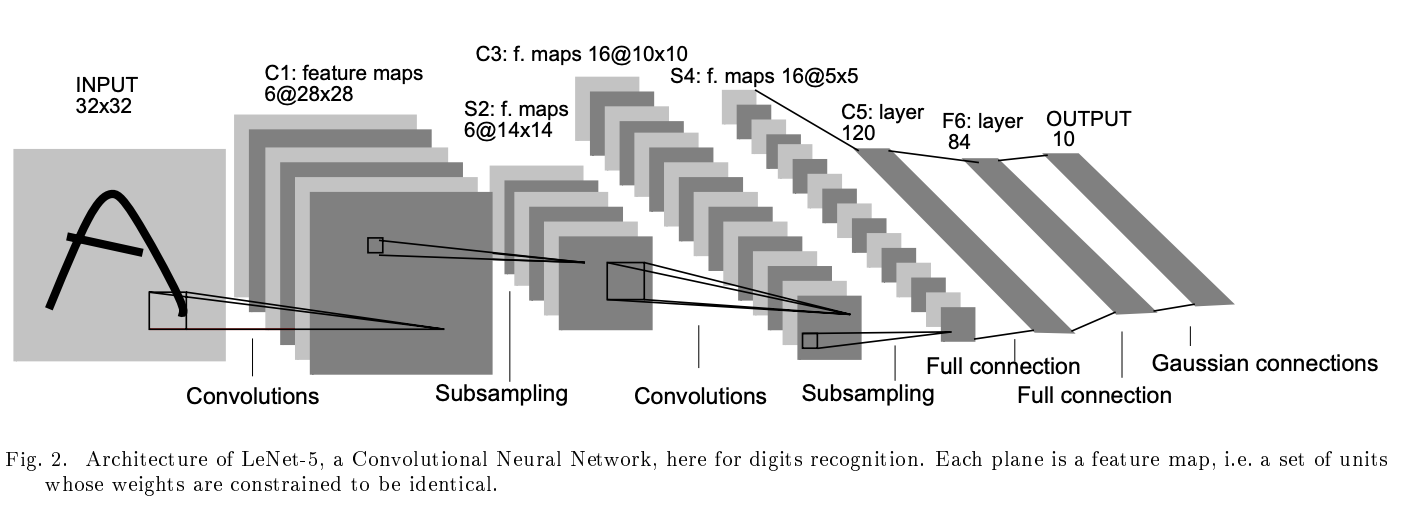

Let's implememt one of the classical convolutional network and apply it for CIFAR-10. Here is the link for the [original paper](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) of LeNet5 introduced by Yann LeCun and colleagues in 1998. The original implementation of LeNet5 has Tanh as nonlinearities. In 2012, AlexNet famously set off the deep learning revolution. AlexNet is based on LeNet, with two main innovations: (1) making it deeper by adding a few extra layers and (2) replacing the tanh activation functions by ReLU to improve training. Here we'll the original LeNet5 architecture to keep the compute requirements small, but work with the more modern ReLU activation functions.

One more thing we change in the original network is the number of input channels as LeNet5 was designed for grayscale MNIST dataset, where each picture has 1 channel, while for RGB pictures we have 3 channels in the input data.


In [34]:
class LeNet5(nn.Module):

    def __init__(self, n_classes, in_channels=3):
        super(LeNet5, self).__init__()
        
        self.feature_extractor = nn.Sequential(            
            nn.Conv2d(in_channels=in_channels, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=n_classes)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [35]:
## TODO: define network, put it to the device and train mode
lenet = LeNet5(n_classes=10, in_channels=3).to(device)
lenet.train()

LeNet5(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)

For a quick overview of models, torchsummary.summary is quite helpful  
comment: You can also import predefined architectures from `torchvision` and run `torchsummary.summary` on them to get a quick overview

In [36]:
## TODO: run torchsummary.summary on the LeNet5 and your MLP model. What do you see?

# torchsummary on LeNet5 and MLP
torchsummary.summary(lenet, (3, 32, 32))
torchsummary.summary(mlp, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              ReLU-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              ReLU-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
            Conv2d-7            [-1, 120, 1, 1]          48,120
              ReLU-8            [-1, 120, 1, 1]               0
            Linear-9                   [-1, 84]          10,164
             ReLU-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

- LeNet5 has only 62,006 parameters total — very small!
- MLP has ~28MB of parameters — much larger despite being "simpler", because fully connected layers with large widths (2048, 512) have enormous numbers of weights
- ReLU and pooling have 0 parameters — they're just operations, nothing to learn
- LeNet5 is far more parameter efficient than MLP because convolutions share weights across the image

In [37]:
## TODO: define loss function and optimizer

# define loss function and optimizer
optimizer_lenet = torch.optim.Adam(lenet.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()



In [38]:
## TODO: train with 20 epochs

# train with 20 epochs
num_epochs = 20
lenet_losses, lenet_val_losses, lenet_accs, lenet_val_accs = run_training(
    lenet, optimizer_lenet, loss_fn, device, num_epochs, train_loader, test_loader
)

Epoch 20/20 | train loss: 0.952 | val loss: 1.035 | train acc: 0.665 | val acc: 0.638: 100%|██████████| 20/20 [03:00<00:00,  9.00s/it]


## Analysis 

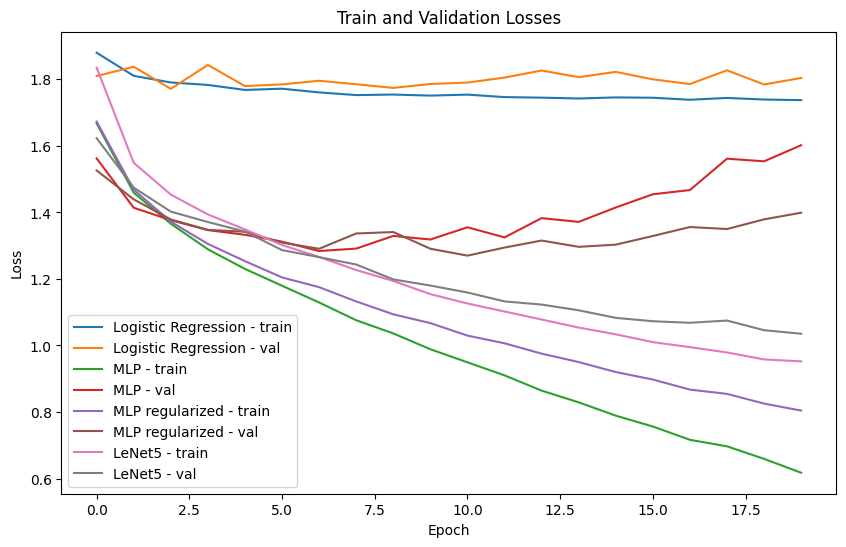

In [39]:
## TODO: Plot both train and val losses for all models. 
## What do you see?

# Plot train and val losses for all models
plt.figure(figsize=(10, 6))
plt.plot(lr_losses, label='Logistic Regression - train')
plt.plot(lr_val_losses, label='Logistic Regression - val')
plt.plot(mlp_losses, label='MLP - train')
plt.plot(mlp_val_losses, label='MLP - val')
plt.plot(mlp_reg_losses, label='MLP regularized - train')
plt.plot(mlp_reg_val_losses, label='MLP regularized - val')
plt.plot(lenet_losses, label='LeNet5 - train')
plt.plot(lenet_val_losses, label='LeNet5 - val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.show()

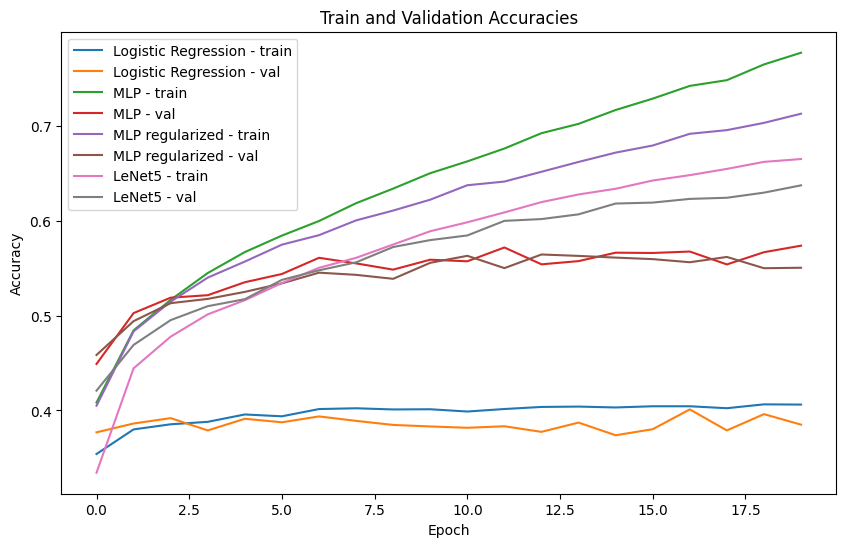

In [40]:
## TODO: Plot both train and val accuracies for all models. 
## What do you see?

# Plot train and val accuracies for all models
plt.figure(figsize=(10, 6))
plt.plot(lr_accs, label='Logistic Regression - train')
plt.plot(lr_val_accs, label='Logistic Regression - val')
plt.plot(mlp_accs, label='MLP - train')
plt.plot(mlp_val_accs, label='MLP - val')
plt.plot(mlp_reg_accs, label='MLP regularized - train')
plt.plot(mlp_reg_val_accs, label='MLP regularized - val')
plt.plot(lenet_accs, label='LeNet5 - train')
plt.plot(lenet_val_accs, label='LeNet5 - val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Validation Accuracies')
plt.legend()
plt.show()

LeNet5 achieves the best validation accuracy with the least overfitting, despite having far fewer parameters than MLP, because convolutions are much better suited for images.

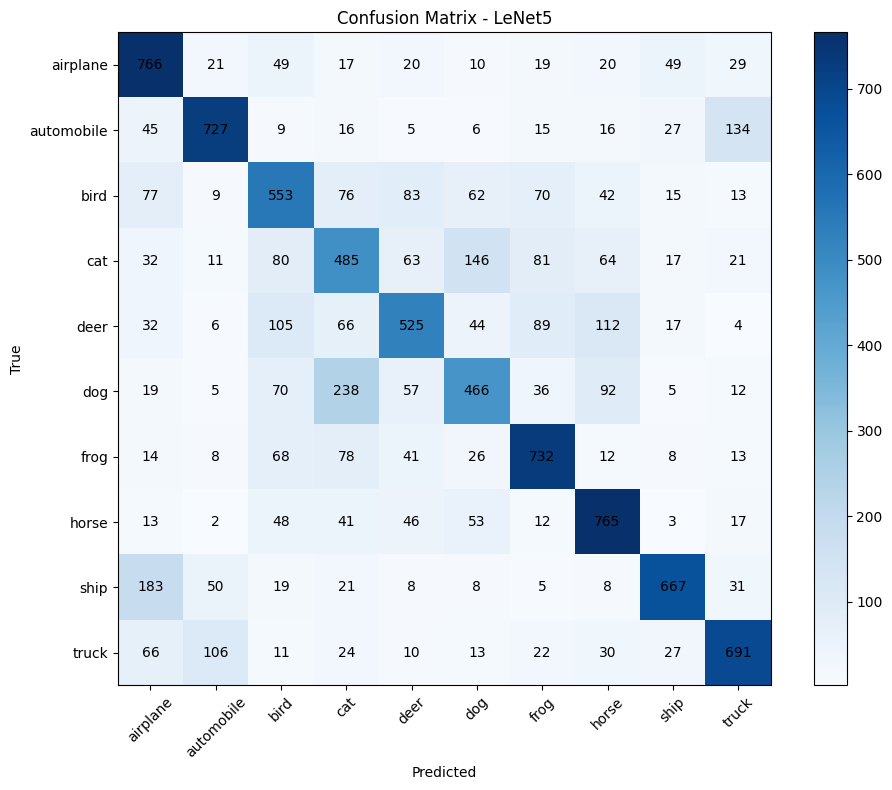

In [41]:
## TODO: Plot the confusion matrix for LeNet5

# Plot confusion matrix for LeNet5
confusion = calc_confusion_values(test_loader, lenet, device)
classes = test_loader.dataset.classes

plt.figure(figsize=(10, 8))
plt.imshow(confusion, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LeNet5')

# add numbers inside the cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, confusion[i, j].item(), ha='center', va='center')

plt.tight_layout()
plt.show()

## Questions
* How did regularization change the performance of the MLP? Why?
* Explain the confusion matrix for LeNet5. What do you see there?
* Explain the difference in performance between linear regression, MLP, and LeNet5.
* Why are convolutions better suited for pictures? Which properties of images do they exploit?
* Is it important to redefine an optimizer for each different model, training? What about loss functions?


Regularization slightly reduced overfitting — the gap between training and validation accuracy got smaller. It did this by penalizing large weights, forcing the model to learn simpler, more generalizable patterns. However the improvement was modest because the MLP architecture itself is fundamentally not well suited for images.

The diagonal shows correct predictions. The off-diagonal entries show confusions — for example cats and dogs are frequently confused with each other, as are automobiles and trucks. This makes intuitive sense as these classes look visually similar.

- Logistic Regression (~40%): too simple, can only learn linear boundaries
- MLP (~57% val): more powerful but overfits badly, treats each pixel independently
- LeNet5 (~64% val): best generalization, exploits spatial structure of images through convolutions


They exploit two key properties of images:
- Local structure — nearby pixels are related (edges, textures)
- Translation invariance — a cat is a cat regardless of where it is in the image. Convolutions share the same weights across the whole image, which is much more efficient than fully connected layers.

Yes for optimizers — each optimizer must point to the specific model's parameters, so you need a separate one per model. Using the wrong optimizer would update the wrong model's weights.
Not necessarily for loss functions — CrossEntropyLoss has no parameters and is stateless, so the same instance can be reused across all models.

## Additional experiments (Optional)
* Try to replace CIFAR10 dataset with MNIST. What do you notice? Why? Try to explain the differences in terms of variance or dataset complexity
